# PROJECT 2 : FIRST NEW VERSION OF SPR FUNCTION
This consist of using OLS + VAR (1) to improove the results of the interpolation function

## Import libraries

In [1]:
import numpy as np           # For numerical computing
import pandas as pd          # For data manipulation and analysis
import matplotlib.pyplot as plt  # For plotting and visualization
import scipy                 # For scientific computing
import sklearn               # For machine learning
import geopandas as gpd      # For geospatial data
import rasterio              # For raster data processing
import xarray                # For working with labeled multi-dimensional arrays
import tensorflow as tf      # For deep learning and neural networks
import torch                 # For deep learning with PyTorch
import seaborn as sns        # For statistical data visualization
import plotly.express as px  # For interactive plots
import statsmodels.api as sm  # For statistical modeling
import folium               # For interactive maps
import networkx as nx        # For complex networks
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import random
import os
from sklearn.utils import resample
import joblib  # for saving data
from multiprocessing import Pool
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from joblib import Parallel, delayed
from tqdm import tqdm
from pykrige.ok import OrdinaryKriging
from skgstat import Variogram
from pykrige.uk import UniversalKriging
from pykrige.rk import Krige
from shapely.geometry import Point
import geopandas as gpd
import warnings
from pyproj import CRS, Transformer
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

2026-04-29 16:16:59.687885: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 16:16:59.711065: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 16:17:00.078151: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Auto saving my script every 60 seconds

In [2]:
%autosave 60

Autosaving every 60 seconds


# Loading data

In [3]:
# RCM DATA
data_rcm_pr_matched = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_pr_matched.csv", index_col=0)
data_rcm_tasmin_matched = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmin_matched.csv", index_col=0)
data_rcm_tasmax_matched = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmax_matched.csv", index_col=0)
match_precip = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/match_precip.csv", index_col=0)
match_tmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/match_tmin.csv", index_col=0)
match_tmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/match_tmax.csv", index_col=0)

# OBSERVATION DATA

In [4]:
data_obs_precip = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_precip_2yr_clean.csv",
    index_col=0
)
data_obs_precip[data_obs_precip < 0.5] = 0

data_obs_tmin = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmin_2yr_clean.csv",
    index_col=0
)

data_obs_tmax = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmax_2yr_clean.csv",
    index_col=0
)

# Load interpolated data

In [5]:
# SPR OBS
spr_obs_pr = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ols_pr.csv", index_col=0)
spr_obs_pr[spr_obs_pr < 0.5] = 0
spr_obs_tmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ols_tmin.csv", index_col=0)
spr_obs_tmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ols_tmax.csv", index_col=0)

# SPR ANO
spr_ano_pr = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_pr.csv", index_col=0)
spr_ano_pr[spr_ano_pr < 0.5] = 0
spr_ano_tmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_tmin.csv", index_col=0)
spr_ano_tmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_tmax.csv", index_col=0)

# SPR ANO VAR
spr_ano_var_pr = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_var_pr.csv", index_col=0)
spr_ano_var_pr[spr_ano_var_pr < 0.5] = 0
spr_ano_var_tmin = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_var_tmin.csv", index_col=0)
spr_ano_var_tmax = pd.read_csv("/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/spr_ano_var_tmax.csv", index_col=0)

# Defining period and indexes

In [6]:
n_years_obs = 2 # number of years in the observation period
n_years_ano = 30 # number of years in the anomaly period

## Define the seed : Set the random seed for reproducibility
my_seed = 2244677 # seed for reproducibility

## Function to calculate anomalies : mensual climatologies with monthly daily means

In [7]:
def monthly_climatology(df):
    """
    Compute monthly climatology from a daily-timeseries DataFrame.
    Assumes non-leap years (365 days). Uses full years only.
    1. Computes the mean for each day of the month across all years.
    2. Then averages these daily means for each month to get the monthly mean.

    Parameters
    ----------
    df : pandas.DataFrame
        Daily data with shape (Njours_total, Nstations)

    Returns
    -------
    climatologie : pandas.DataFrame
        Monthly climatology (12 x Nstations) indexed by month names.
    """
    Njours_total, Nstations = df.shape
    Nyears = Njours_total // 365
    if Nyears < 1:
        raise ValueError("Input must contain at least 365 days to compute climatology.")

    # Reshape to (Nyears, 365, Nstations)
    data_reshaped = df.to_numpy().reshape(Nyears, 365, Nstations)

    # Days per month for a non-leap year and month names
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_names = ["January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"]

    monthly_means = {}
    start = 0
    for name, ndays in zip(month_names, days_by_month):
        day_indices = list(range(start, start + ndays))
        start += ndays
        # data_month: (Nyears, ndays, Nstations) : select days and data for the month
        data_month = data_reshaped[:, day_indices, :]
        # mean over days by month for each year -> (Nyears, Nstations)
        daily_mean_per_year = data_month.mean(axis=1) # (Nyears, Nstations)
        # mean over years -> (Nstations,)
        monthly_mean = daily_mean_per_year.mean(axis=0) # (Nstations,)
        monthly_means[name] = monthly_mean # Store the monthly mean

    climatologie = pd.DataFrame.from_dict(monthly_means, orient="index", columns=df.columns) # (12, Nstations)
    return climatologie

# Data preparation : defining data on the period and region considered

In [8]:
# Assuming data.pr, data.tasmin, data.tasmax are numpy arrays or pandas DataFrames
# Define these with actual data or load from files
# Example placeholders (replace these with real data):
# data_pr, data_tasmin, data_tasmax = ...

# Example: data should be NumPy arrays or similar
# Using .loc because region_colnames are column names
# rcm_period and obs_period are row positions and region_colnames are column names
## RCM data
data_pr_grid = data_rcm_pr_matched
data_pr_grid[data_pr_grid < 0.5] = 0  # remove noise
data_tasmin_grid = data_rcm_tasmin_matched
data_tasmax_grid = data_rcm_tasmax_matched


## Climatology data
## Climatology for precipitation, tmin and tmax
climatology_pr = monthly_climatology(data_pr_grid)
climatology_tasmin = monthly_climatology(data_tasmin_grid)
climatology_tasmax = monthly_climatology(data_tasmax_grid)


## Observed data
data_pr_obs = data_obs_precip
data_pr_obs[data_pr_obs < 0.5] = 0  # remove noise
# data_pr_obs[data_pr_obs <= 1e-5] = 1e-5  # lower bound
# data_pr_obs = np.log(np.exp(data_pr_obs) - 1)  # transform for positivity
data_tasmin_obs = data_obs_tmin
data_tasmax_obs = data_obs_tmax


## Original data for comparison
data_pr_obs_orig = data_obs_precip
data_pr_obs_orig[data_pr_obs_orig < 0.5] = 0  # remove noise
data_tasmin_obs_orig = data_obs_tmin
data_tasmax_obs_orig = data_obs_tmax

# Calculate anomalies

In [9]:
def climatology_fun(climatology, nyears):
    # Daily distribution per month (non-leap year)
    days_by_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    month_index = np.repeat(np.arange(12), days_by_month)  # 0-based month indices
    climatology_year = climatology.iloc[month_index, :]         # Shape: (365, n_cols)
    
    # Repeat for the number of years
    climatology_nyears = np.tile(climatology_year, (nyears, 1))  # Shape: (365 * nyears, n_cols)
    return climatology_nyears

# For grid data (30 years)
anomaly_pr_grid = data_pr_grid / climatology_fun(climatology_pr, nyears=n_years_ano) - 1  # multiplicative for precipitation. Not centered
anomaly_tasmin_grid = data_tasmin_grid - climatology_fun(climatology_tasmin, nyears=n_years_ano) # additive for temperature
anomaly_tasmax_grid = data_tasmax_grid - climatology_fun(climatology_tasmax, nyears=n_years_ano) # additive for temperature

# For observations (10 years)
anomaly_pr_obs = data_pr_obs / climatology_fun(climatology_pr, nyears=n_years_obs) - 1  # multiplicative for precipitation
anomaly_tasmin_obs = data_tasmin_obs - climatology_fun(climatology_tasmin, nyears=n_years_obs) # additive for temperature
anomaly_tasmax_obs = data_tasmax_obs - climatology_fun(climatology_tasmax, nyears=n_years_obs) # additive for temperature

# A copy of original anomalies for comparison
anomaly_pr_obs_orig = anomaly_pr_obs.copy()
anomaly_tasmin_obs_orig = anomaly_tasmin_obs.copy()
anomaly_tasmax_obs_orig = anomaly_tasmax_obs.copy()

## Scale climatology for GRID and OBS on the same shape as anomalies

In [10]:
# For RCM data (30 years)
clim_pr_grid = climatology_fun(climatology_pr, nyears=n_years_ano)
clim_tasmin_grid = climatology_fun(climatology_tasmin, nyears=n_years_ano)
clim_tasmax_grid = climatology_fun(climatology_tasmax, nyears=n_years_ano)

# For observed data (10 years)
clim_pr_obs = climatology_fun(climatology_pr, nyears=n_years_obs)
clim_tasmin_obs = climatology_fun(climatology_tasmin, nyears=n_years_obs)
clim_tasmax_obs = climatology_fun(climatology_tasmax, nyears=n_years_obs)

# Train and test set

## Densite : 3 stations train

In [11]:
# # --- Custom rounding function (round .5 up) ---
# perc_10 = 0.90  # % of columns to set as test
# def custom_round(x):
#     return int(np.ceil(x) if x - int(x) == 0.5 else round(x))

# # Select test indexes
# np.random.seed(my_seed)
# random.seed(my_seed)
# n_days_10, n_cols_10 = data_pr_obs.shape
# n_test_10 = custom_round(perc_10 * n_cols_10)
# test_indexes_10 = np.random.choice(n_cols_10, size=n_test_10, replace=False)
# test_indexes_10.sort()  # Sort for easier reading
# train_indexes_10 = [i for i in range(n_cols_10) if i not in test_indexes_10]

In [12]:
# Select test indexes
np.random.seed(my_seed)
random.seed(my_seed)

## PRECIP
n_days_pr, n_cols_pr = data_pr_obs.shape
n_test_pr = 12 # n_train = 3
test_indexes_pr = np.random.choice(n_cols_pr, size=n_test_pr, replace=False)
test_indexes_pr.sort()  # Sort for easier reading
train_indexes_pr = [i for i in range(n_cols_pr) if i not in test_indexes_pr]

# Select test indexes
np.random.seed(my_seed)
random.seed(my_seed)

# TMIN
n_days_tasmin, n_cols_tasmin = data_tasmin_obs.shape
n_test_tasmin = 40 # n_train_tasmin = 3
test_indexes_tasmin = np.random.choice(n_cols_tasmin, size=n_test_tasmin, replace=False)
test_indexes_tasmin.sort()  # Sort for easier reading
train_indexes_tasmin = [i for i in range(n_cols_tasmin) if i not in test_indexes_tasmin]

# Select test indexes
np.random.seed(my_seed)
random.seed(my_seed)

# TMAX
n_days_tasmax, n_cols_tasmax = data_tasmax_obs.shape
n_test_tasmax = 40 # n_train_tasmax = 3
test_indexes_tasmax = np.random.choice(n_cols_tasmax, size=n_test_tasmax, replace=False)
test_indexes_tasmax.sort()  # Sort for easier reading
train_indexes_tasmax = [i for i in range(n_cols_tasmax) if i not in test_indexes_tasmax]

# # --- Set test indices to NaN in all datasets ---
# data_pr_obs.iloc[:, test_indexes_pr] = np.nan
# data_tasmin_obs.iloc[:, test_indexes_tasmin] = np.nan
# data_tasmax_obs.iloc[:, test_indexes_tasmax] = np.nan
# anomaly_pr_obs.iloc[:, test_indexes_pr] = np.nan
# anomaly_tasmin_obs.iloc[:, test_indexes_tasmin] = np.nan
# anomaly_tasmax_obs.iloc[:, test_indexes_tasmax] = np.nan

## Convert all data to nympy

In [13]:
# Convert all data to numpy
## Precipitation
data_pr_obs_np = data_pr_obs.values if isinstance(data_pr_obs, pd.DataFrame) else data_pr_obs
data_pr_obs_orig_np = data_pr_obs_orig.values if isinstance(data_pr_obs_orig, pd.DataFrame) else data_pr_obs_orig
anomaly_pr_grid_np = anomaly_pr_grid.values if isinstance(anomaly_pr_grid, pd.DataFrame) else anomaly_pr_grid
anomaly_pr_obs_np = anomaly_pr_obs.values if isinstance(anomaly_pr_obs, pd.DataFrame) else anomaly_pr_obs
# clim_pr_grid_np = clim_pr_grid.values if isinstance(clim_pr_grid, pd.DataFrame) else clim_pr_grid
# clim_pr_obs_np = clim_pr_obs.values if isinstance(clim_pr_obs, pd.DataFrame) else clim_pr_obs

## Tmin
data_tasmin_obs_np = data_tasmin_obs.values if isinstance(data_tasmin_obs, pd.DataFrame) else data_tasmin_obs
data_tasmin_obs_orig_np = data_tasmin_obs_orig.values if isinstance(data_tasmin_obs_orig, pd.DataFrame) else data_tasmin_obs_orig
anomaly_tasmin_grid_np = anomaly_tasmin_grid.values if isinstance(anomaly_tasmin_grid, pd.DataFrame) else anomaly_tasmin_grid
anomaly_tasmin_obs_np = anomaly_tasmin_obs.values if isinstance(anomaly_tasmin_obs, pd.DataFrame) else anomaly_tasmin_obs
# clim_tasmin_grid_np = clim_tasmin_grid.values if isinstance(clim_tasmin_grid, pd.DataFrame) else clim_tasmin_grid
# clim_tasmin_obs_np = clim_tasmin_obs.values if isinstance(clim_tasmin_obs, pd.DataFrame) else clim_tasmin_obs

## Tmax
data_tasmax_obs_np = data_tasmax_obs.values if isinstance(data_tasmax_obs, pd.DataFrame) else data_tasmax_obs
data_tasmax_obs_orig_np = data_tasmax_obs_orig.values if isinstance(data_tasmax_obs_orig, pd.DataFrame) else data_tasmax_obs_orig
anomaly_tasmax_grid_np = anomaly_tasmax_grid.values if isinstance(anomaly_tasmax_grid, pd.DataFrame) else anomaly_tasmax_grid
anomaly_tasmax_obs_np = anomaly_tasmax_obs.values if isinstance(anomaly_tasmax_obs, pd.DataFrame) else anomaly_tasmax_obs
# clim_tasmax_grid_np = clim_tasmax_grid.values if isinstance(clim_tasmax_grid, pd.DataFrame) else clim_tasmax_grid
# clim_tasmax_obs_np = clim_tasmax_obs.values if isinstance(clim_tasmax_obs, pd.DataFrame) else clim_tasmax_obs

# ## Original data
# data_pr_obs_orig_np = data_pr_obs_orig.values if isinstance(data_pr_obs_orig, pd.DataFrame) else data_pr_obs_orig
# data_tasmin_obs_orig_np = data_tasmin_obs_orig.values if isinstance(data_tasmin_obs_orig, pd.DataFrame) else data_tasmin_obs_orig
# data_tasmax_obs_orig_np = data_tasmax_obs_orig.values if isinstance(data_tasmax_obs_orig, pd.DataFrame) else data_tasmax_obs_orig

# Original anomaly data for comparison
anomaly_pr_obs_orig_np = anomaly_pr_obs_orig.values if isinstance(anomaly_pr_obs_orig, pd.DataFrame) else anomaly_pr_obs_orig
anomaly_tasmin_obs_orig_np = anomaly_tasmin_obs_orig.values if isinstance(anomaly_tasmin_obs_orig, pd.DataFrame) else anomaly_tasmin_obs_orig
anomaly_tasmax_obs_orig_np = anomaly_tasmax_obs_orig.values if isinstance(anomaly_tasmax_obs_orig, pd.DataFrame) else anomaly_tasmax_obs_orig

In [14]:
# SPR OBS
spr_obs_pr = spr_obs_pr.values if isinstance(spr_obs_pr, pd.DataFrame) else spr_obs_pr
spr_obs_tmin = spr_obs_tmin.values if isinstance(spr_obs_tmin, pd.DataFrame) else spr_obs_tmin
spr_obs_tmax = spr_obs_tmax.values if isinstance(spr_obs_tmax, pd.DataFrame) else spr_obs_tmax

# SPR ANO
spr_ano_pr = spr_ano_pr.values if isinstance(spr_ano_pr, pd.DataFrame) else spr_ano_pr
spr_ano_tmin = spr_ano_tmin.values if isinstance(spr_ano_tmin, pd.DataFrame) else spr_ano_tmin
spr_ano_tmax = spr_ano_tmax.values if isinstance(spr_ano_tmax, pd.DataFrame) else spr_ano_tmax

# SPR ANO VAR
spr_ano_var_pr = spr_ano_var_pr.values if isinstance(spr_ano_var_pr, pd.DataFrame) else spr_ano_var_pr
spr_ano_var_tmin = spr_ano_var_tmin.values if isinstance(spr_ano_var_tmin, pd.DataFrame) else spr_ano_var_tmin
spr_ano_var_tmax = spr_ano_var_tmax.values if isinstance(spr_ano_var_tmax, pd.DataFrame) else spr_ano_var_tmax

## Compute anomalies

In [15]:
# SPR OBS
anomaly_obs_pr = spr_obs_pr / clim_pr_obs - 1 # multiplicative for precipitation
anomaly_obs_tmin = spr_obs_tmin / clim_tasmin_obs
anomaly_obs_tmax = spr_obs_tmax / clim_tasmax_obs
# SPR ANO
anomaly_ano_pr = spr_ano_pr / clim_pr_obs - 1 # multiplicative for precipitation
anomaly_ano_tmin = spr_ano_tmin / clim_tasmin_obs
anomaly_ano_tmax = spr_ano_tmax / clim_tasmax_obs
# SPR ANO VAR
anomaly_ano_var_pr = spr_ano_var_pr / clim_pr_obs - 1 # multiplicative for precipitation
anomaly_ano_var_tmin = spr_ano_var_tmin / clim_tasmin_obs
anomaly_ano_var_tmax = spr_ano_var_tmax / clim_tasmax_obs

# Performance against observations

In [16]:
def stats_performance(mod, obs):
    # obs = observations, original data
    # mod = interpolated data from the model
    def convert_to_np(X):
        return X.to_numpy() if isinstance(X, pd.DataFrame) else np.asarray(X, dtype=float)

    # def mean_daily_bias(mod, obs): # Mean Daily Bias
    #     M, O = convert_to_np(mod), convert_to_np(obs)
    #     diff = M - O
    #     daily_bias = np.nanmean(diff, axis=1)
    #     return np.nanmean(daily_bias)

    # Spatial RMSE: average RMSE across all stations for each day, then average over days
    def mean_daily_rmse(mod, obs): # Spatial RMSE
        M, O = convert_to_np(mod), convert_to_np(obs)
        diff = M - O
        daily_rmse = np.sqrt(np.nanmean(diff**2, axis=1)) # average over stations
        return np.nanmean(daily_rmse)
    
    # Temporal RMSE: average over days first, then average over stations
    def mean_station_rmse(mod, obs): # Temporal RMSE
        M, O = convert_to_np(mod), convert_to_np(obs)
        diff = M - O
        daily_rmse = np.sqrt(np.nanmean(diff**2, axis=0)) # average over days
        return np.nanmean(daily_rmse)

    # Average daily NSE over all days and locations
    def mean_daily_nse(mod, obs, eps=1e-12): # Mean daily NSE (Nash–Sutcliffe Efficiency) on wet days
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_nse = []
        for s in range(M.shape[1]):
            y_hat, y_true = M[:,s], O[:,s]
            y_true_bar = np.mean(y_true)
            Num = np.sum((y_true - y_hat) ** 2)
            Den = np.sum((y_true - y_true_bar) ** 2)
            # Avoid divide by zero
            if Den < eps:
                daily_nse.append(np.nan)
                continue
            nse = 1 - Num / Den
            daily_nse.append(nse)
        return np.nanmean(daily_nse)

    # Average daily KGE over all days and locations
    def mean_daily_kge(mod, obs, eps=1e-12):
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_kge = []
        for s in range(M.shape[1]):
            y_hat = M[:, s]
            y_true = O[:, s]
            mask = np.isfinite(y_hat) & np.isfinite(y_true)
            if mask.sum() < 2:
                daily_kge.append(np.nan)
                continue
            a, b = y_hat[mask], y_true[mask]
            mu_a, mu_b = a.mean(), b.mean()
            sigma_a, sigma_b = a.std(), b.std()
            # require obs mean and obs std to be nonzero
            if abs(mu_b) < eps or sigma_b < eps:
                daily_kge.append(np.nan)
                continue
            # correlation only when variances are sufficient
            if sigma_a < eps or sigma_b < eps:
                daily_kge.append(np.nan)
                continue
            r_corr = np.corrcoef(a, b)[0, 1]
            if not np.isfinite(r_corr):
                daily_kge.append(np.nan)
                continue
            beta = mu_a / mu_b
            gamma = (sigma_a / (mu_a + eps)) / (sigma_b / (mu_b + eps))
            kge = 1 - np.sqrt((r_corr - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2)
            daily_kge.append(kge)
        return np.nanmean(daily_kge)

    # Average daily SSIM over all days and locations
    def mean_daily_ssim(mod, obs, K1=0.01, K2=0.03, L=None, eps=1e-12):
        """
        Compute per-day SSIM and return the mean over days.
        K1/K2: typical SSIM constants (fractions of dynamic range L).
        If L is None, per-day dynamic range is used.
        """
        M, O = convert_to_np(mod), convert_to_np(obs)
        daily_ssim = []
        for s in range(M.shape[1]):
            a, b = M[:, s], O[:, s]
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 2:
                daily_ssim.append(np.nan)
                continue
            a, b = a[mask], b[mask]

            mu_a, mu_b = a.mean(), b.mean()
            var_a = np.mean((a - mu_a) ** 2)
            var_b = np.mean((b - mu_b) ** 2)
            sig_a, sig_b = np.sqrt(var_a), np.sqrt(var_b)
            cov_ab = np.mean((a - mu_a) * (b - mu_b))

            # determine dynamic range for this day if not provided
            if L is None:
                L_day = np.max(b) - np.min(b)
                if L_day < eps:
                    L_day = max(np.abs(mu_b), eps)
            else:
                L_day = L

            # Constants for SSIM formula as did Wang et al., 2004
            C1 = (K1 * L_day) ** 2
            C2 = (K2 * L_day) ** 2
            C3 = C2 / 2.0

            # luminance, contrast and structure terms
            l = (2 * mu_a * mu_b + C1) / (mu_a**2 + mu_b**2 + C1)
            c = (2 * sig_a * sig_b + C2) / (var_a + var_b + C2)
            s = (cov_ab + C3) / (sig_a * sig_b + C3)

            daily_ssim.append(l * c * s)

        return np.nanmean(daily_ssim)
    
    # Average daily PSNR over all days and locations
    def mean_daily_psnr(mod, obs, eps=1e-12):
        M, O = np.array(mod), np.array(obs)
        daily_psnr = []
        for t in range(M.shape[0]):
            a, b = M[t], O[t]
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 2:
                daily_psnr.append(np.nan)
                continue
            a, b = a[mask], b[mask]
            mse = np.mean((a - b)**2)
            # Per-day maximum if not given
            max_v = np.max(b)
            max_v = max(max_v, eps)  # Avoid zero max
            if mse == 0:
                daily_psnr.append(np.nan)  # Perfect match
                continue
            psnr_day = 10 * np.log10((max_v**2) / mse)
            daily_psnr.append(psnr_day)
        return np.nanmean(daily_psnr)
    
    # Return all metrics as a table
    # bias = mean_daily_bias(mod, obs)
    rmse_s = mean_daily_rmse(mod, obs)
    rmse_t = mean_station_rmse(mod, obs)
    nse = mean_daily_nse(mod, obs)
    kge = mean_daily_kge(mod, obs)
    ssim = mean_daily_ssim(mod, obs)
    # psnr = mean_daily_psnr(mod, obs)

    metrics = pd.DataFrame({
        # "Bias": [bias],
        "RMSE_s": [rmse_s],
        "RMSE_t": [rmse_t],
        "NSE": [nse],
        "KGE": [kge],
        "SSIM": [ssim],
        # "PSNR": [psnr]
    })

    return metrics



# Temporal structure
import scipy.signal as sps

def _acf_masked(x, nlags=10):
    """Compute ACF for a 1D series with NaN handling."""
    x = np.asarray(x, dtype=float)
    mask = np.isfinite(x)
    if mask.sum() < 3:
        return np.full(nlags+1, np.nan)
    s = x[mask]
    acfs = [1.0]
    for lag in range(1, nlags+1):
        if s.size <= lag+1:
            acfs.append(np.nan)
            continue
        r = np.corrcoef(s[:-lag], s[lag:])[0,1]
        acfs.append(r if np.isfinite(r) else np.nan)
    return np.array(acfs)

def _fill_for_psd(x):
    """Fill NaNs for PSD computation via linear interpolation."""
    s = pd.Series(x.astype(float))
    if s.isna().all():
        return np.zeros_like(x)
    s = s.interpolate(limit_direction='both').fillna(s.mean())
    return s.values

def compute_temporal_metrics(mod_ols, mod_ano, mod_ano_var, obs, nlags=10, psd_nperseg=256):
    """
    Compute temporal structure metrics comparing interpolated vs observed data.
    
    Parameters
    ----------
    mod_ols : pd.DataFrame or np.ndarray
        OLS model/interpolated data, shape (T, N_stations)
    mod_ano : pd.DataFrame or np.ndarray
        ANO model/interpolated data, shape (T, N_stations)
    mod_ano_var : pd.DataFrame or np.ndarray
        ANO_VAR model/interpolated data, shape (T, N_stations)
    obs : pd.DataFrame or np.ndarray
        Observed data, shape (T, N_stations)
    nlags : int, default=10
        Number of lags for ACF computation
    psd_nperseg : int, default=256
        Segment length for Welch PSD estimation
    
    Returns
    -------
    dict
        Dictionary containing:
        - mean_abs_lag1_acf_mod_ols: Mean absolute lag-1 autocorrelation (OLS model)
        - mean_abs_lag1_acf_mod_ano: Mean absolute lag-1 autocorrelation (ANO model)
        - mean_abs_lag1_acf_mod_ano_var: Mean absolute lag-1 autocorrelation (ANO_VAR model)
        - mean_abs_lag1_acf_obs: Mean absolute lag-1 autocorrelation (observed)
        - acf_decay_mean_mod_ols: Mean ACF decay over all lags (OLS model)
        - acf_decay_mean_mod_ano: Mean ACF decay over all lags (ANO model)
        - acf_decay_mean_mod_ano_var: Mean ACF decay over all lags (ANO_VAR model)
        - acf_decay_mean_obs: Mean ACF decay over all lags (observed)
        - psd_cosine_similarity: Cosine similarity between mean PSDs
        - acf_lags_matrix_mod_ols: Full ACF matrix for OLS model (N_stations, nlags+1)
        - acf_lags_matrix_mod_ano: Full ACF matrix for ANO model (N_stations, nlags+1)
        - acf_lags_matrix_mod_ano_var: Full ACF matrix for ANO_VAR model (N_stations, nlags+1)
        - acf_lags_matrix_obs: Full ACF matrix for obs (N_stations, nlags+1)
    """
    M_ols = mod_ols.to_numpy() if isinstance(mod_ols, pd.DataFrame) else np.asarray(mod_ols)
    M_ano = mod_ano.to_numpy() if isinstance(mod_ano, pd.DataFrame) else np.asarray(mod_ano)
    M_ano_var = mod_ano_var.to_numpy() if isinstance(mod_ano_var, pd.DataFrame) else np.asarray(mod_ano_var)
    O = obs.to_numpy() if isinstance(obs, pd.DataFrame) else np.asarray(obs)
    T, D = M_ols.shape

    # Per-station ACF computation for MODEL OLS
    acf_lags_mod_ols = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ols[j, :] = _acf_masked(M_ols[:, j], nlags=nlags)

    # Per-station ACF computation for MODEL ANO
    acf_lags_mod_ano = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ano[j, :] = _acf_masked(M_ano[:, j], nlags=nlags)

    # Per-station ACF computation for MODEL ANO VAR
    acf_lags_mod_ano_var = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_mod_ano_var[j, :] = _acf_masked(M_ano_var[:, j], nlags=nlags)

    # Per-station ACF computation for OBSERVATIONS
    acf_lags_obs = np.zeros((D, nlags+1))
    for j in range(D):
        acf_lags_obs[j, :] = _acf_masked(O[:, j], nlags=nlags)

    # Metrics from ACF - MODEL OLS
    mean_abs_lag1_acf_mod_ols = np.nanmean(np.abs(acf_lags_mod_ols[:, 1]))
    acf_decay_mod_ols = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ols[:, 1:]), axis=1))

    # Metrics from ACF - MODEL ANO
    mean_abs_lag1_acf_mod_ano = np.nanmean(np.abs(acf_lags_mod_ano[:, 1]))
    acf_decay_mod_ano = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ano[:, 1:]), axis=1))

    # Metrics from ACF - MODEL ANO VAR
    mean_abs_lag1_acf_mod_ano_var = np.nanmean(np.abs(acf_lags_mod_ano_var[:, 1]))
    acf_decay_mod_ano_var = np.nanmean(np.nanmean(np.abs(acf_lags_mod_ano_var[:, 1:]), axis=1))

    # Metrics from ACF - OBSERVATIONS
    mean_abs_lag1_acf_obs = np.nanmean(np.abs(acf_lags_obs[:, 1]))
    acf_decay_obs = np.nanmean(np.nanmean(np.abs(acf_lags_obs[:, 1:]), axis=1))

    # Spectral similarity: compute mean PSD vector (Welch) for obs and mod
    psd_obs_list, psd_mod_list = [], []
    for j in range(D):
        o = _fill_for_psd(O[:, j])
        m_ols = _fill_for_psd(M_ols[:, j])
        m_ano = _fill_for_psd(M_ano_var[:, j])
        m_ano_var = _fill_for_psd(M_ano_var[:, j])
        o = o - np.mean(o)
        m_ols = m_ols - np.mean(m_ols)
        m_ano = m_ano - np.mean(m_ano)
        m_ano_var = m_ano_var - np.mean(m_ano_var)
        f_o, Pxx_o = sps.welch(o, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ols, Pxx_m_ols = sps.welch(m_ols, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ano, Pxx_m_ano = sps.welch(m_ano, nperseg=min(psd_nperseg, max(8, T//2)))
        f_m_ano_var, Pxx_m_ano_var = sps.welch(m_ano_var, nperseg=min(psd_nperseg, max(8, T//2)))
        L = min(Pxx_o.size, Pxx_m_ols.size, Pxx_m_ano.size, Pxx_m_ano_var.size)
        psd_obs_list.append(Pxx_o[:L])
        psd_mod_list.append(Pxx_m_ols[:L])
    
    if len(psd_obs_list) == 0:
        psd_cosine_sim = np.nan
    else:
        mean_psd_obs = np.nanmean(np.vstack(psd_obs_list), axis=0)
        mean_psd_mod = np.nanmean(np.vstack(psd_mod_list), axis=0)
        num = np.dot(mean_psd_obs, mean_psd_mod)
        den = (np.linalg.norm(mean_psd_obs) * np.linalg.norm(mean_psd_mod)) + 1e-12
        psd_cosine_sim = float(num/den)

    return {
        "mean_abs_lag1_acf_mod_ols": float(mean_abs_lag1_acf_mod_ols),
        "mean_abs_lag1_acf_mod_ano": float(mean_abs_lag1_acf_mod_ano),
        "mean_abs_lag1_acf_mod_ano_var": float(mean_abs_lag1_acf_mod_ano_var),
        "mean_abs_lag1_acf_obs": float(mean_abs_lag1_acf_obs),
        "acf_decay_mean_mod_ols": float(acf_decay_mod_ols),
        "acf_decay_mean_mod_ano": float(acf_decay_mod_ano),
        "acf_decay_mean_mod_ano_var": float(acf_decay_mod_ano_var),
        "acf_decay_mean_obs": float(acf_decay_obs),
        "psd_cosine_similarity": float(psd_cosine_sim),
        "acf_lags_matrix_mod_ols": acf_lags_mod_ols,
        "acf_lags_matrix_mod_ano": acf_lags_mod_ano,
        "acf_lags_matrix_mod_ano_var": acf_lags_mod_ano_var,
        "acf_lags_matrix_obs": acf_lags_obs
    }


# ANALYSIS AT THE CHOOSEN DENSITY

In [17]:
test_indexes_pr

array([ 0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## Performance against observation

In [18]:
# Performance metrics (observations vs interpolated anomalies) for VAR and OLS
#PRECIP
stats_spr_ano_var_pr = stats_performance(
    mod=spr_ano_var_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

stats_spr_ano_pr = stats_performance(
    mod=spr_ano_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

stats_spr_obs_pr = stats_performance(
    mod=spr_obs_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

# TMIN
stats_spr_ano_var_tmin = stats_performance(
    mod=spr_ano_var_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

stats_spr_ano_tmin = stats_performance(
    mod=spr_ano_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

stats_spr_obs_tmin = stats_performance(
    mod=spr_obs_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

# TMAX
stats_spr_ano_var_tmax = stats_performance(
    mod=spr_ano_var_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)

stats_spr_ano_tmax = stats_performance(
    mod=spr_ano_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)

stats_spr_obs_tmax = stats_performance(
    mod=spr_obs_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)


def build_perf_table(var_name):
    model_tables_by_var = {
        "PR": {
            "OLS": stats_spr_obs_pr,
            "ANO": stats_spr_ano_pr,
            "VAR": stats_spr_ano_var_pr,
        },
        "TMIN": {
            "OLS": stats_spr_obs_tmin,
            "ANO": stats_spr_ano_tmin,
            "VAR": stats_spr_ano_var_tmin,
        },
        "TMAX": {
            "OLS": stats_spr_obs_tmax,
            "ANO": stats_spr_ano_tmax,
            "VAR": stats_spr_ano_var_tmax,
        },
    }

    if var_name not in model_tables_by_var:
        raise ValueError(f"Unsupported variable '{var_name}'. Use one of {list(model_tables_by_var.keys())}.")

    rows = []
    for model_label, df_stats in model_tables_by_var[var_name].items():
        tmp = df_stats.copy()
        tmp.insert(0, "Model", f"SPR-{model_label}")
        rows.append(tmp)

    merged = pd.concat(rows, axis=0, ignore_index=True)
    merged.insert(0, "Variable", var_name)

    print("\n" + "#" * 52)
    print(f"Performance against observations: {var_name}")
    print("#" * 52)
    print(merged.to_string(index=False))

    return merged

# Build combined summary table (VAR first, then OLS for each variable)
perf_summary = pd.concat(
    [build_perf_table("PR"), build_perf_table("TMIN"), build_perf_table("TMAX")],
    axis=0,
    ignore_index=True,
)



####################################################
Performance against observations: PR
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
      PR SPR-OLS 2.544588 4.520406 0.343225 0.650403 0.676068
      PR SPR-ANO 2.006168 3.389692 0.636675 0.706557 0.780337
      PR SPR-VAR 2.006204 3.389794 0.636690 0.706079 0.780076

####################################################
Performance against observations: TMIN
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE       KGE     SSIM
    TMIN SPR-OLS 2.471973 2.500422 0.946111 -3.728196 0.564182
    TMIN SPR-ANO 1.989489 2.012071 0.966081 -2.522130 0.650759
    TMIN SPR-VAR 1.989487 2.012064 0.966081 -2.521979 0.650759

####################################################
Performance against observations: TMAX
####################################################
Variable   Model   RMSE_s   RMSE_t      NSE      KGE     SSIM
  

# RMSE with mean, median, variance, IC

In [19]:
# Compute spatial RMSE : daily rmse averaged over stations. Then compute mean, median, variance, and IQR of the daily RMSE across days.
def compute_spatial_rmse_stats(mod, obs):
    M, O = mod.to_numpy() if isinstance(mod, pd.DataFrame) else np.asarray(mod), obs.to_numpy() if isinstance(obs, pd.DataFrame) else np.asarray(obs)
    diff = M - O
    daily_rmse = np.sqrt(np.nanmean(diff**2, axis=1)) # average over stations
    rmse_mean = np.nanmean(daily_rmse)
    rmse_median = np.nanmedian(daily_rmse)
    rmse_variance = np.nanvar(daily_rmse)
    # rmse_iqr = np.nanpercentile(daily_rmse, 75) - np.nanpercentile(daily_rmse, 25)
    rmse_CI_2_5 = np.nanpercentile(daily_rmse, 2.5)
    rmse_CI_97_5 = np.nanpercentile(daily_rmse, 97.5)
    return {
        "rmse_mean": float(rmse_mean),
        "rmse_median": float(rmse_median),
        "rmse_variance": float(rmse_variance),
        # "rmse_iqr": float(rmse_iqr),
        "rmse_ci_2_5": float(rmse_CI_2_5),
        "rmse_ci_97_5": float(rmse_CI_97_5)
    }

#PR
rmse_stats_spr_ano_var_pr = compute_spatial_rmse_stats(
    mod=spr_ano_var_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

rmse_stats_spr_ano_pr = compute_spatial_rmse_stats(
    mod=spr_ano_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

rmse_stats_spr_obs_pr = compute_spatial_rmse_stats(
    mod=spr_obs_pr[:, test_indexes_pr],
    obs=data_pr_obs_orig_np[:, test_indexes_pr]
)

# TMIN
rmse_stats_spr_ano_var_tmin = compute_spatial_rmse_stats(
    mod=spr_ano_var_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

rmse_stats_spr_ano_tmin = compute_spatial_rmse_stats(
    mod=spr_ano_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

rmse_stats_spr_obs_tmin = compute_spatial_rmse_stats(
    mod=spr_obs_tmin[:, test_indexes_tasmin],
    obs=data_tasmin_obs_orig_np[:, test_indexes_tasmin]
)

# TMAX
rmse_stats_spr_ano_var_tmax = compute_spatial_rmse_stats(
    mod=spr_ano_var_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)   

rmse_stats_spr_ano_tmax = compute_spatial_rmse_stats(
    mod=spr_ano_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)

rmse_stats_spr_obs_tmax = compute_spatial_rmse_stats(
    mod=spr_obs_tmax[:, test_indexes_tasmax],
    obs=data_tasmax_obs_orig_np[:, test_indexes_tasmax]
)

In [20]:
# Build combined RMSE stats table (VAR first, then OLS for each variable)

# Expose this mapping for downstream cells (e.g., CELL 39)
model_stats_by_var = {
    "PR": {
        "OLS": rmse_stats_spr_obs_pr,
        "ANO": rmse_stats_spr_ano_pr,
        "VAR": rmse_stats_spr_ano_var_pr,
    },
    "TMIN": {
        "OLS": rmse_stats_spr_obs_tmin,
        "ANO": rmse_stats_spr_ano_tmin,
        "VAR": rmse_stats_spr_ano_var_tmin,
    },
    "TMAX": {
        "OLS": rmse_stats_spr_obs_tmax,
        "ANO": rmse_stats_spr_ano_tmax,
        "VAR": rmse_stats_spr_ano_var_tmax,
    },
}

# Print RMSE stats as one table
def build_rmse_stats_table(var_name):
    if var_name not in model_stats_by_var:
        raise ValueError(f"Unsupported variable '{var_name}'. Use one of {list(model_stats_by_var.keys())}.")

    rows = []
    for model_label, stats_dict in model_stats_by_var[var_name].items():
        row = {"Model": f"SPR-{model_label}"}
        row.update(stats_dict)
        rows.append(row)

    df = pd.DataFrame(rows)
    df.insert(0, "Variable", var_name)

    print("\n" + "#" * 52)
    print(f"Spatial RMSE statistics: {var_name}")
    print("#" * 52)
    print(df.to_string(index=False))

    return df
rmse_stats_table_pr = build_rmse_stats_table("PR")
rmse_stats_table_tmin = build_rmse_stats_table("TMIN")
rmse_stats_table_tmax = build_rmse_stats_table("TMAX")


####################################################
Spatial RMSE statistics: PR
####################################################
Variable   Model  rmse_mean  rmse_median  rmse_variance  rmse_ci_2_5  rmse_ci_97_5
      PR SPR-OLS   2.544588     1.063798      14.374307          0.0     12.876834
      PR SPR-ANO   2.006168     1.011132       7.879019          0.0      9.680153
      PR SPR-VAR   2.006204     1.011308       7.879497          0.0      9.685179

####################################################
Spatial RMSE statistics: TMIN
####################################################
Variable   Model  rmse_mean  rmse_median  rmse_variance  rmse_ci_2_5  rmse_ci_97_5
    TMIN SPR-OLS   2.471973     2.317399       0.799550     1.183770      4.575153
    TMIN SPR-ANO   1.989489     1.855468       0.399264     1.059136      3.488752
    TMIN SPR-VAR   1.989487     1.855463       0.399264     1.059135      3.488754

####################################################
Spatial RM

# Boxplot of RMSE

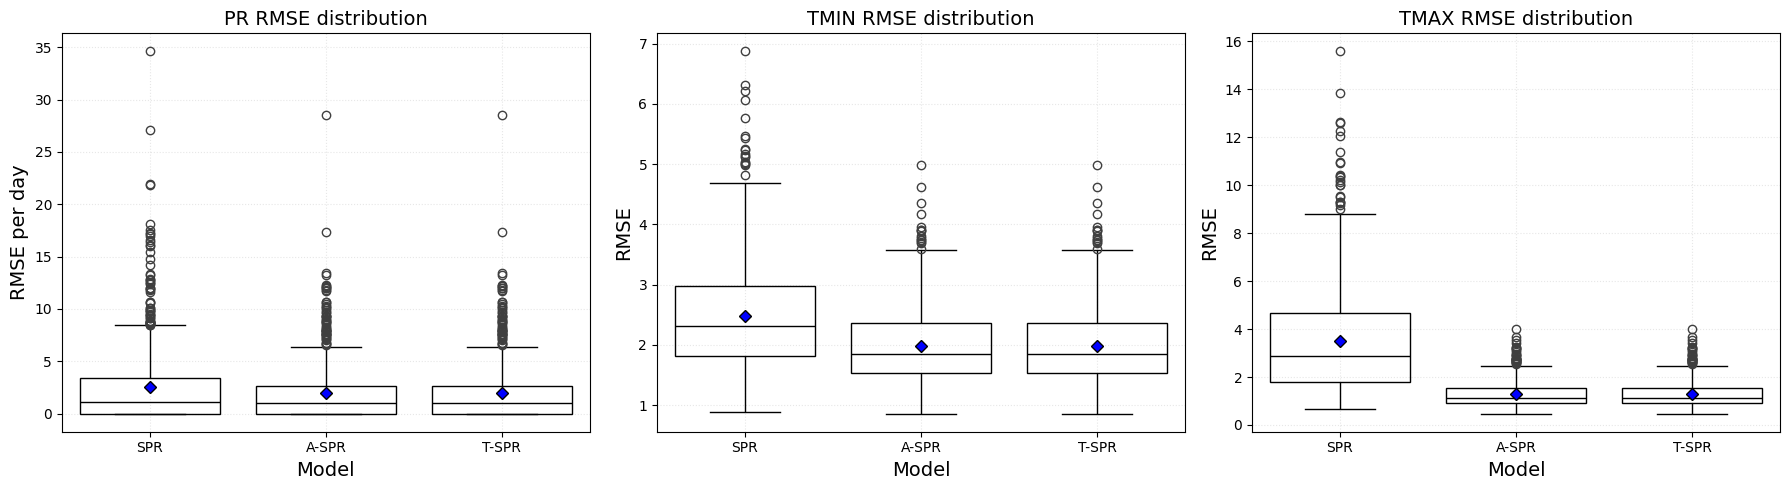

In [21]:
# Boxplots using full RMSE distributions (10% density), not mean RMSE summaries

def rmse_vector(mod, obs, axis=0):
    """
    RMSE without final averaging.
    axis=0 -> RMSE per station (over time)
    axis=1 -> RMSE per day (over stations)
    """
    diff = mod - obs
    return np.sqrt(np.nanmean(diff**2, axis=axis))

def build_rmse_dist_df_10(axis=0):
    rows = []

    cfg = {
        "PR": {
            "SPR": (spr_obs_pr[:, test_indexes_pr], data_pr_obs_orig_np[:, test_indexes_pr]),
            "A-SPR": (spr_ano_pr[:, test_indexes_pr], data_pr_obs_orig_np[:, test_indexes_pr]),
            "T-SPR": (spr_ano_var_pr[:, test_indexes_pr], data_pr_obs_orig_np[:, test_indexes_pr]),
        },
        "TMIN": {
            "SPR": (spr_obs_tmin[:, test_indexes_tasmin], data_tasmin_obs_orig_np[:, test_indexes_tasmin]),
            "A-SPR": (spr_ano_tmin[:, test_indexes_tasmin], data_tasmin_obs_orig_np[:, test_indexes_tasmin]),
            "T-SPR": (spr_ano_var_tmin[:, test_indexes_tasmin], data_tasmin_obs_orig_np[:, test_indexes_tasmin]),
        },
        "TMAX": {
            "SPR": (spr_obs_tmax[:, test_indexes_tasmax], data_tasmax_obs_orig_np[:, test_indexes_tasmax]),
            "A-SPR": (spr_ano_tmax[:, test_indexes_tasmax], data_tasmax_obs_orig_np[:, test_indexes_tasmax]),
            "T-SPR": (spr_ano_var_tmax[:, test_indexes_tasmax], data_tasmax_obs_orig_np[:, test_indexes_tasmax]),
        },
    }

    for var, models in cfg.items():
        for model_name, (mod, obs) in models.items():
            vals = rmse_vector(mod, obs, axis=axis)
            rows.append(pd.DataFrame({
                "Variable": var,
                "Model": model_name,
                "RMSE": vals
            }))

    return pd.concat(rows, ignore_index=True)

def plot_rmse_boxplots_10(axis=0, show_mean_labels=True):
    rmse_dist_10 = build_rmse_dist_df_10(axis=axis)

    model_order = ["SPR", "A-SPR", "T-SPR"]
    _, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, var in zip(axes, ["PR", "TMIN", "TMAX"]):
        sub = rmse_dist_10[rmse_dist_10["Variable"] == var]

        sns.boxplot(
            data=sub,
            x="Model",
            y="RMSE",
            order=model_order,
            ax=ax,
            boxprops=dict(facecolor="none", edgecolor="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            medianprops=dict(color="black"),
            showmeans=True,
            meanprops=dict(
                marker="D",
                markerfacecolor="blue",
                markeredgecolor="black",
                markersize=6
            )
        )

        # Optional: print numeric mean values next to each mean marker.
        means = sub.groupby("Model", as_index=False)["RMSE"].mean()
        means = means.set_index("Model").reindex(model_order).reset_index()
        if show_mean_labels:
            y_min, y_max = ax.get_ylim()
            y_offset = 0.02 * (y_max - y_min)
            for i, row in means.iterrows():
                ax.text(i, row["RMSE"] + y_offset, f"{row['RMSE']:.2f}",
                        ha="center", va="bottom", fontsize=12, color="blue")

        ax.set_title(f"{var} RMSE distribution", fontsize=14)
        ax.set_xlabel("Model", fontsize=14)
        ax.set_ylabel("RMSE", fontsize=14)
        ax.grid(True, alpha=0.3, linestyle=":")

    ylabel = "RMSE per station" if axis == 0 else "RMSE per day"
    axes[0].set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# axis=0: all station RMSE values
# axis=1: all daily RMSE values
plot_rmse_boxplots_10(axis=1, show_mean_labels=False)

## Temporal structure

In [22]:
# ===== PRECIPITATION =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: PRECIPITATION")
print("=" * 42)

temps_spr_pr = compute_temporal_metrics(
    spr_obs_pr[:, test_indexes_pr],
    spr_ano_pr[:, test_indexes_pr],
    spr_ano_var_pr[:, test_indexes_pr],
    data_pr_obs_orig_np[:, test_indexes_pr],
    nlags=10,
)

# ===== TMIN =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMIN")
print("=" * 42)

temps_spr_tmin = compute_temporal_metrics(
    spr_obs_tmin[:, test_indexes_tasmin],
    spr_ano_tmin[:, test_indexes_tasmin],
    spr_ano_var_tmin[:, test_indexes_tasmin],
    data_tasmin_obs_orig_np[:, test_indexes_tasmin],
    nlags=10,
)


# ===== TMAX =====
print("\n" + "=" * 42)
print("TEMPORAL STRUCTURE METRICS: TMAX")
print("=" * 42)

temps_spr_tmax = compute_temporal_metrics(
    spr_obs_tmax[:, test_indexes_tasmax],
    spr_ano_tmax[:, test_indexes_tasmax],
    spr_ano_var_tmax[:, test_indexes_tasmax],
    data_tasmax_obs_orig_np[:, test_indexes_tasmax],
    nlags=10,
)



TEMPORAL STRUCTURE METRICS: PRECIPITATION



TEMPORAL STRUCTURE METRICS: TMIN

TEMPORAL STRUCTURE METRICS: TMAX


In [23]:
def print_temporal_metrics_comparison(metrics, variable_name):
    print(f"\n{'='*50}")
    print(f"TEMPORAL STRUCTURE METRICS: {variable_name}")
    print(f"{'='*50}")

    lag1_obs = metrics["mean_abs_lag1_acf_obs"]
    lag1_ols = metrics["mean_abs_lag1_acf_mod_ols"]
    lag1_ano = metrics["mean_abs_lag1_acf_mod_ano"]
    lag1_ano_var = metrics["mean_abs_lag1_acf_mod_ano_var"]

    decay_obs = metrics["acf_decay_mean_obs"]
    decay_ols = metrics["acf_decay_mean_mod_ols"]
    decay_ano = metrics["acf_decay_mean_mod_ano"]
    decay_ano_var = metrics["acf_decay_mean_mod_ano_var"]

    psd_sim = metrics["psd_cosine_similarity"]

    comparison_data_10 = {
        "Metric": ["Mean |ACF(lag-1)|", "Mean ACF Decay", "PSD Cosine Similarity"],
        "SPR_OLS": [f"{lag1_ols:.4f}", f"{decay_ols:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO": [f"{lag1_ano:.4f}", f"{decay_ano:.4f}", f"{psd_sim:.4f}"],
        "SPR_ANO_VAR": [f"{lag1_ano_var:.4f}", f"{decay_ano_var:.4f}", f"{psd_sim:.4f}"],
        "Observations": [f"{lag1_obs:.4f}", f"{decay_obs:.4f}", "—"],
    }

    df_comparison_10 = pd.DataFrame(comparison_data_10)
    print(df_comparison_10.to_string(index=False))
    print(f"{'='*50}\n")
    return df_comparison_10


print("\n" + "="*50)
print("TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS")
print("="*50)

print_temporal_metrics_comparison(temps_spr_pr, "PR")
print_temporal_metrics_comparison(temps_spr_tmin, "TMIN")
print_temporal_metrics_comparison(temps_spr_tmax, "TMAX")



TEMPORAL STRUCTURE ANALYSIS: VAR vs ANO vs OLS

TEMPORAL STRUCTURE METRICS: PR
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.0889  0.1098      0.1102       0.0852
       Mean ACF Decay  0.0304  0.0430      0.0430       0.0361
PSD Cosine Similarity  0.9699  0.9699      0.9699            —


TEMPORAL STRUCTURE METRICS: TMIN
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.8991  0.9113      0.9113       0.8952
       Mean ACF Decay  0.8289  0.8325      0.8325       0.8162
PSD Cosine Similarity  0.9999  0.9999      0.9999            —


TEMPORAL STRUCTURE METRICS: TMAX
               Metric SPR_OLS SPR_ANO SPR_ANO_VAR Observations
    Mean |ACF(lag-1)|  0.8808  0.9310      0.9310       0.9231
       Mean ACF Decay  0.8098  0.8587      0.8588       0.8505
PSD Cosine Similarity  0.9995  0.9995      0.9995            —



,Metric,SPR_OLS,SPR_ANO,SPR_ANO_VAR,Observations
0,Mean |ACF(lag-1)|,0.8808,0.9310,0.9310,0.9231
1,Mean ACF Decay,0.8098,0.8587,0.8588,0.8505
2,PSD Cosine Similarity,0.9995,0.9995,0.9995,—


## Graphical comparison of temporal structure

### Combined PSD Comparison (TMIN and TMAX)

Generating Combined PSD Comparison Plot


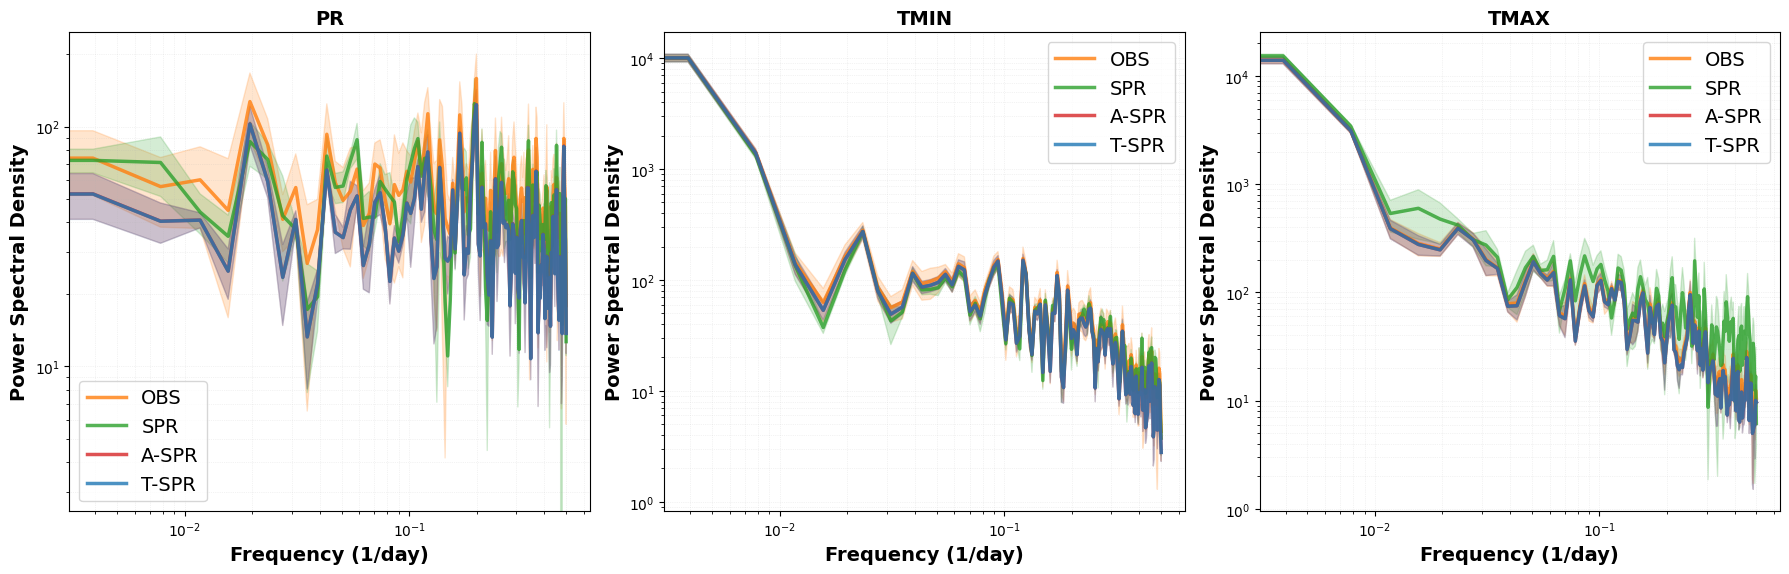

In [24]:
def plot_combined_psd_comparison(
    obs_pr,
    mod_ols_pr,
    mod_ano_pr,
    mod_ano_var_pr,
    obs_tmin,
    mod_ols_tmin,
    mod_ano_tmin,
    mod_ano_var_tmin,
    obs_tmax,
    mod_ols_tmax,
    mod_ano_tmax,
    mod_ano_var_tmax,
    psd_nperseg=256,
):
    """
    Plot Power Spectral Density comparison for both TMIN and TMAX in a single figure.
    Shows Observations vs VAR vs OLS.
    """
    import scipy.signal as sps

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    series = [
        (obs_pr, mod_ols_pr, mod_ano_pr, mod_ano_var_pr, "PR", axes[0]),
        (obs_tmin, mod_ols_tmin, mod_ano_tmin, mod_ano_var_tmin, "TMIN", axes[1]),
        (obs_tmax, mod_ols_tmax, mod_ano_tmax, mod_ano_var_tmax, "TMAX", axes[2]),
    ]

    colors = {"OBS": "#ff7f0e", "VAR": "#1f77b4", "ANO": "#d62728", "OLS": "#2ca02c"}

    for obs, mod_ols, mod_ano, mod_ano_var, var_name, ax in series:
        M_ols = mod_ols.to_numpy() if hasattr(mod_ols, "to_numpy") else np.asarray(mod_ols)
        M_ano = mod_ano.to_numpy() if hasattr(mod_ano, "to_numpy") else np.asarray(mod_ano)
        M_ano_var = mod_ano_var.to_numpy() if hasattr(mod_ano_var, "to_numpy") else np.asarray(mod_ano_var)

        O = obs.to_numpy() if hasattr(obs, "to_numpy") else np.asarray(obs)
        T, D = M_ano_var.shape

        def compute_mean_psd(arr):
            psd_list, freqs_list = [], []
            for j in range(D):
                x = _fill_for_psd(arr[:, j])
                x = x - np.mean(x)
                f, Pxx = sps.welch(x, nperseg=min(psd_nperseg, max(8, T // 2)))
                psd_list.append(Pxx)
                freqs_list.append(f)
            L = min(min(len(p) for p in psd_list), min(len(f) for f in freqs_list))
            psd_arr = np.vstack([p[:L] for p in psd_list])
            freqs = np.vstack([f[:L] for f in freqs_list])
            return np.nanmean(freqs, axis=0), np.nanmean(psd_arr, axis=0), np.nanstd(psd_arr, axis=0)

        f_obs, mean_obs, std_obs = compute_mean_psd(O)
        f_ano_var, mean_ano_var, std_ano_var = compute_mean_psd(M_ano_var)
        f_ano, mean_ano, std_ano = compute_mean_psd(M_ano)
        f_ols, mean_ols, std_ols = compute_mean_psd(M_ols)

        ax.loglog(f_obs, mean_obs, "-", label="OBS", linewidth=2.5, color=colors["OBS"], alpha=0.8)
        ax.fill_between(f_obs, mean_obs - std_obs, mean_obs + std_obs, alpha=0.2, color=colors["OBS"])

        ax.loglog(f_ols, mean_ols, "-", label="SPR", linewidth=2.5, color=colors["OLS"], alpha=0.8)
        ax.fill_between(f_ols, mean_ols - std_ols, mean_ols + std_ols, alpha=0.2, color=colors["OLS"])

        ax.loglog(f_ano, mean_ano, "-", label="A-SPR", linewidth=2.5, color=colors["ANO"], alpha=0.8)
        ax.fill_between(f_ano, mean_ano - std_ano, mean_ano + std_ano, alpha=0.2, color=colors["ANO"])
        
        ax.loglog(f_ano_var, mean_ano_var, "-", label="T-SPR", linewidth=2.5, color=colors["VAR"], alpha=0.8)
        ax.fill_between(f_ano_var, mean_ano_var - std_ano_var, mean_ano_var + std_ano_var, alpha=0.2, color=colors["VAR"])


        ax.set_xlabel("Frequency (1/day)", fontsize=14, fontweight="bold")
        ax.set_ylabel("Power Spectral Density", fontsize=14, fontweight="bold")
        ax.set_title(f"{var_name}", fontsize=14, fontweight="bold")
        ax.legend(fontsize=14, loc="lower left" if var_name == "PR" else "upper right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5, which="both")

    fig.suptitle("", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig

print("=" * 60)
print("Generating Combined PSD Comparison Plot")
print("=" * 60)
fig_combined_psd = plot_combined_psd_comparison(
    obs_pr=data_pr_obs_orig_np[:, test_indexes_pr],
    mod_ols_pr=spr_obs_pr[:, test_indexes_pr],
    mod_ano_pr=spr_ano_pr[:, test_indexes_pr],
    mod_ano_var_pr=spr_ano_var_pr[:, test_indexes_pr],
    obs_tmin=data_tasmin_obs_orig_np[:, test_indexes_tasmin],
    mod_ols_tmin=spr_obs_tmin[:, test_indexes_tasmin],
    mod_ano_tmin=spr_ano_tmin[:, test_indexes_tasmin],
    mod_ano_var_tmin=spr_ano_var_tmin[:, test_indexes_tasmin],
    obs_tmax=data_tasmax_obs_orig_np[:, test_indexes_tasmax],
    mod_ols_tmax=spr_obs_tmax[:, test_indexes_tasmax],
    mod_ano_tmax=spr_ano_tmax[:, test_indexes_tasmax],
    mod_ano_var_tmax=spr_ano_var_tmax[:, test_indexes_tasmax],
)
plt.show()

### Combined ACF Comparison (TMIN and TMAX)

Generating Combined ACF Comparison Plot


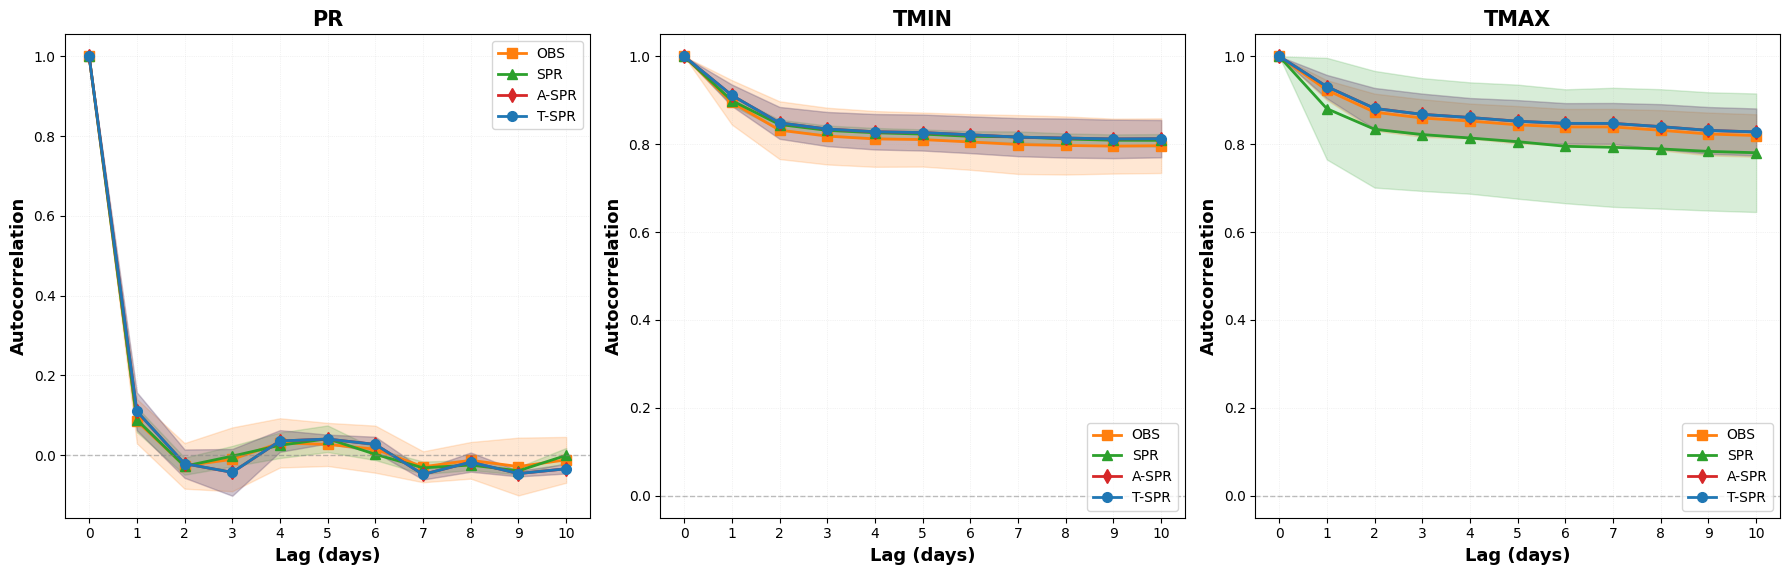

In [25]:
def plot_combined_acf_comparison(
    metrics_pr,
    metrics_tmin,
    metrics_tmax,
):
    """
    Plot ACF comparison for TMIN and TMAX with Observations vs ANO vs VAR vs OLS.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    series = [
        (metrics_pr, "PR", axes[0]),
        (metrics_tmin, "TMIN", axes[1]),
        (metrics_tmax, "TMAX", axes[2]),
    ]

    colors = {"OBS": "#ff7f0e", "ANO": "#d62728", "VAR": "#1f77b4", "OLS": "#2ca02c"}

    for metrics, var_name, ax in series:
        # Correct keys from compute_temporal_metrics output
        acf_obs = metrics["acf_lags_matrix_obs"]
        acf_mod_ols = metrics["acf_lags_matrix_mod_ols"]
        acf_mod_ano = metrics["acf_lags_matrix_mod_ano"]
        acf_mod_ano_var = metrics["acf_lags_matrix_mod_ano_var"]

        mean_acf_obs = np.nanmean(acf_obs, axis=0)
        std_acf_obs = np.nanstd(acf_obs, axis=0)

        mean_acf_ano = np.nanmean(acf_mod_ano, axis=0)
        std_acf_ano = np.nanstd(acf_mod_ano, axis=0)

        mean_acf_ano_var = np.nanmean(acf_mod_ano_var, axis=0)
        std_acf_ano_var = np.nanstd(acf_mod_ano_var, axis=0)

        mean_acf_ols = np.nanmean(acf_mod_ols, axis=0)
        std_acf_ols = np.nanstd(acf_mod_ols, axis=0)

        nlags = len(mean_acf_obs) - 1
        lags = np.arange(nlags + 1)

        ax.plot(lags, mean_acf_obs, "s-", label="OBS", linewidth=2, markersize=7, color=colors["OBS"])
        ax.fill_between(lags, mean_acf_obs - 2 * std_acf_obs, mean_acf_obs + 2 * std_acf_obs, alpha=0.18, color=colors["OBS"])

        ax.plot(lags, mean_acf_ols, "^-", label="SPR", linewidth=2, markersize=7, color=colors["OLS"])
        ax.fill_between(lags, mean_acf_ols - 2 * std_acf_ols, mean_acf_ols + 2 * std_acf_ols, alpha=0.18, color=colors["OLS"])

        ax.plot(lags, mean_acf_ano, "d-", label="A-SPR", linewidth=2, markersize=7, color=colors["ANO"])
        ax.fill_between(lags, mean_acf_ano - 2 * std_acf_ano, mean_acf_ano + 2 * std_acf_ano, alpha=0.18, color=colors["ANO"])

        ax.plot(lags, mean_acf_ano_var, "o-", label="T-SPR", linewidth=2, markersize=7, color=colors["VAR"])
        ax.fill_between(lags, mean_acf_ano_var - 2 * std_acf_ano_var, mean_acf_ano_var + 2 * std_acf_ano_var, alpha=0.18, color=colors["VAR"])

        ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_xlabel("Lag (days)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Autocorrelation", fontsize=13, fontweight="bold")
        ax.set_title(var_name, fontsize=15, fontweight="bold")
        ax.legend(fontsize=10, loc="upper right" if var_name == "PR" else "lower right")
        ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.set_xticks(lags)

    fig.suptitle("", fontsize=17, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig


print("=" * 60)
print("Generating Combined ACF Comparison Plot")
print("=" * 60)
fig_combined_acf = plot_combined_acf_comparison(
    temps_spr_pr,
    temps_spr_tmin,
    temps_spr_tmax,
)
plt.show()

## Variabilité inter-journalière

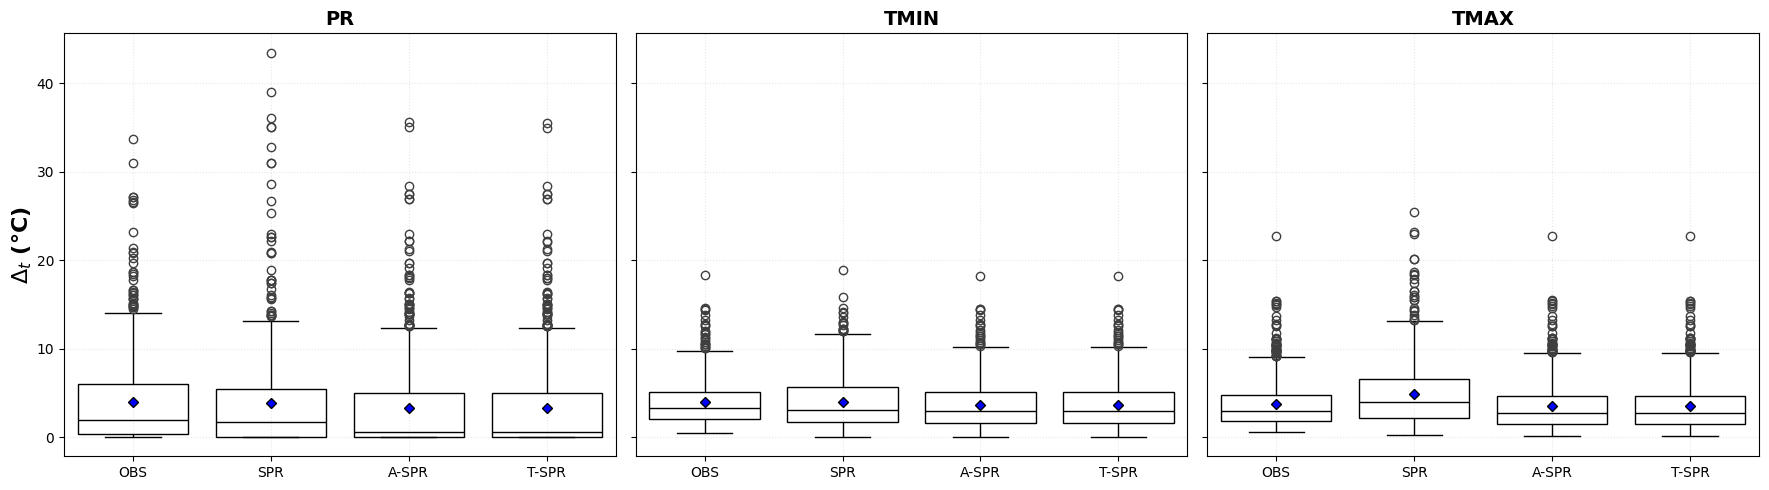


Inter-day variability summary (stress-test density)
Variable Density Method  mean_delta  var_delta
      PR     10%  A-SPR    3.239540  27.204841
      PR     10%    OBS    3.938583  25.324602
      PR     10%    SPR    3.826381  32.295409
      PR     10%  T-SPR    3.235765  27.142795
    TMAX     10%  A-SPR    3.511654   8.348136
    TMAX     10%    OBS    3.727734   7.629489
    TMAX     10%    SPR    4.875537  13.642693
    TMAX     10%  T-SPR    3.510908   8.344246
    TMIN     10%  A-SPR    3.674980   7.779423
    TMIN     10%    OBS    3.983168   6.721485
    TMIN     10%    SPR    3.969897   8.640929
    TMIN     10%  T-SPR    3.674656   7.777909


In [26]:
# Inter-day variability analysis: Δ_t = mean_j |Y[t,j] - Y[t-1,j]|
# Compare OBS vs SPR vs A-SPR vs T-SPR

def interday_delta_series(arr):
    A = arr.to_numpy() if hasattr(arr, "to_numpy") else np.asarray(arr, dtype=float)
    return np.nanmean(np.abs(np.diff(A, axis=0)), axis=1)  # shape (T-1,)

def build_delta_comparison(variable_name, obs, spr, a_spr, t_spr, density_label="0.1%"):
    d_obs = interday_delta_series(obs)
    d_spr = interday_delta_series(spr)
    d_a_spr = interday_delta_series(a_spr)
    d_t_spr = interday_delta_series(t_spr)

    long_df = pd.DataFrame({
        "Variable": variable_name,
        "Density": density_label,
        "Method": np.repeat(["OBS", "SPR", "A-SPR", "T-SPR"],
                            [len(d_obs), len(d_spr), len(d_a_spr), len(d_t_spr)]),
        "Delta": np.concatenate([d_obs, d_spr, d_a_spr, d_t_spr]),
    })

    summary = (
        long_df.groupby(["Variable", "Density", "Method"], as_index=False)["Delta"]
        .agg(mean_delta="mean", var_delta="var")
    )
    return long_df, summary

# --- Build results for 0.1% density ---
delta_pr_df, delta_pr_stats = build_delta_comparison(
    "PR", data_pr_obs_orig_np, spr_obs_pr, spr_ano_pr, spr_ano_var_pr, "10%"
)
delta_tmin_df, delta_tmin_stats = build_delta_comparison(
    "TMIN", data_tasmin_obs_orig_np, spr_obs_tmin, spr_ano_tmin, spr_ano_var_tmin, "10%"
)
delta_tmax_df, delta_tmax_stats = build_delta_comparison(
    "TMAX", data_tasmax_obs_orig_np, spr_obs_tmax, spr_ano_tmax, spr_ano_var_tmax, "10%"
)

delta_all = pd.concat([delta_pr_df, delta_tmin_df, delta_tmax_df], ignore_index=True)
delta_stats = pd.concat([delta_pr_stats, delta_tmin_stats, delta_tmax_stats], ignore_index=True)

# --- Plot: side-by-side boxplots ---
method_order = ["OBS", "SPR", "A-SPR", "T-SPR"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, var in zip(axes, ["PR", "TMIN", "TMAX"]):
    sub = delta_all[delta_all["Variable"] == var]
    sns.boxplot(
        data=sub,
        x="Method",
        y="Delta",
        order=method_order,
        ax=ax,
        boxprops=dict(facecolor="none", edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="blue", markeredgecolor="black", markersize=5),
    )
    ax.set_ylabel("")
    ax.set_title(f"{var}", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    # ax.set_ylabel(r"$\Delta_t$ (°C)", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle=":")

fig.supylabel(r"$\Delta_t$ (°C)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0.005, 0, 1, 1])
plt.show()

# --- Summary table: mean and variance of Δ_t ---
delta_summary = delta_stats.sort_values(["Variable", "Method"]).reset_index(drop=True)

print("\nInter-day variability summary (stress-test density)")
for ax in axes:
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=14)

fig.supylabel(r"$\Delta_t$ (°C)", fontsize=16, fontweight="bold")

print(delta_summary.to_string(index=False))


In [32]:
962.96*24-26000

-2888.959999999999